In [1]:
import geopandas as gpd
import pandas as pd

from shapely.ops import unary_union, linemerge
from shapely.geometry import Point, LineString, MultiLineString
from shapely.geometry import mapping

import folium
from folium import Map, GeoJson

import json



### Berlin einlesen für Proof of concept

<Axes: >

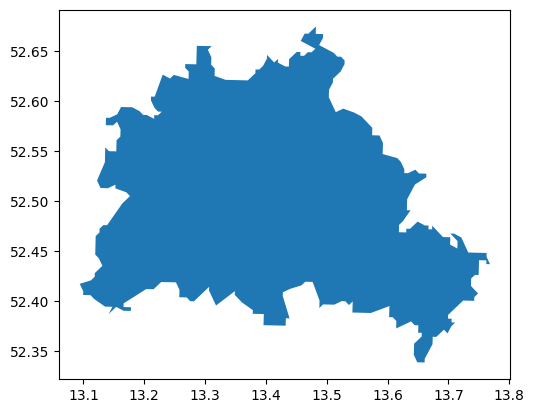

In [2]:
bland = gpd.read_file("https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/main/2_bundeslaender/1_sehr_hoch.geo.json")
bland_fil=bland[bland["id"].isin(["DE-BE"])]
bland_fil.plot()

In [3]:
### schools einlesen

schools_gdf = gpd.read_file("../preprocessing/processed_osm_files/processed_schools_germany_250528.fgb")

schools_gdf

,osm_id,name,amenity,isced_level,source_layer,osm_way_id,geometry
0,1938163084,None,kindergarten,None,points,None,POINT (13.73271 48.58014)
1,None,None,school,None,multipolygons,192729055,"MULTIPOLYGON (((13.66324 48.57875, 13.66286 48..."
2,None,None,school,None,multipolygons,192729054,"MULTIPOLYGON (((13.66328 48.57854, 13.6634 48...."
3,None,Gymnasium Untergriesbach,school,None,multipolygons,192729051,"MULTIPOLYGON (((13.66402 48.5784, 13.66296 48...."
4,None,None,school,None,multipolygons,192729052,"MULTIPOLYGON (((13.66342 48.57824, 13.6634 48...."
...,...,...,...,...,...,...,...
81242,None,Kita Altforweiler,kindergarten,None,multipolygons,161591153,"MULTIPOLYGON (((6.70334 49.27681, 6.70336 49.2..."
81243,None,Grundschule,school,None,multipolygons,252719088,"MULTIPOLYGON (((6.70501 49.27708, 6.70509 49.2..."
81244,None,Kita,kindergarten,None,multipolygons,1250395881,"MULTIPOLYGON (((6.69909 49.25215, 6.69792 49.2..."
81245,None,Grundschule St. Oranna,school,None,multipolygons,238048642,"MULTIPOLYGON (((6.68945 49.26161, 6.68984 49.2..."


In [4]:
schools_gdf["oid"] = schools_gdf.apply(
    lambda row: f"way/{int(row.osm_way_id)}" if pd.notnull(row.osm_way_id) else (
        f"node/{int(row.osm_id)}" if pd.notnull(row.osm_id) else None
    ),
    axis=1
)

In [5]:
schools_gdf_ber=schools_gdf.clip(bland_fil)

In [6]:
schools_gdf_ber.explore()

In [7]:
### laerm einlesen

laerm_gdf = gpd.read_parquet("../preprocessing/laerm/LK_HLQ_road_Den_4110.parquet")

In [8]:
laerm_gdf

,geometry,OBJECTID,id,Lärmpegelklasse,source,measureTim,measureT_1,Shape_Length,Shape_Area
0,"MULTIPOLYGON (((8.50294 50.08582, 8.50294 50.0...",100.0,170100005.0,Lden5559,majorRoadsIncludingAgglomeration,,,3.587244e+06,1.077876e+08
1,"MULTIPOLYGON (((8.19685 50.04457, 8.19683 50.0...",101.0,170200001.0,LdenGreaterThan75,majorRoadsIncludingAgglomeration,,,4.723668e+05,1.983071e+07
2,"MULTIPOLYGON (((8.16961 50.04308, 8.16961 50.0...",102.0,170200002.0,Lden6569,majorRoadsIncludingAgglomeration,,,1.491054e+06,4.374699e+07
3,"MULTIPOLYGON (((8.16971 50.04277, 8.16969 50.0...",103.0,170200003.0,Lden6064,majorRoadsIncludingAgglomeration,,,1.851847e+06,6.603509e+07
4,"MULTIPOLYGON (((8.16947 50.04313, 8.16946 50.0...",104.0,170200004.0,Lden7074,majorRoadsIncludingAgglomeration,,,1.166934e+06,2.656910e+07
...,...,...,...,...,...,...,...,...,...
318,"MULTIPOLYGON (((8.52035 50.03619, 8.52035 50.0...",96.0,170100001.0,LdenGreaterThan75,majorRoadsIncludingAgglomeration,,,8.138433e+05,4.242800e+07
319,"MULTIPOLYGON (((8.48694 50.08919, 8.48695 50.0...",97.0,170100002.0,Lden6569,majorRoadsIncludingAgglomeration,,,2.185452e+06,8.512491e+07
320,"MULTIPOLYGON (((8.48915 50.09233, 8.48915 50.0...",98.0,170100003.0,Lden6064,majorRoadsIncludingAgglomeration,,,2.626765e+06,9.883946e+07
321,"MULTIPOLYGON (((8.48826 50.08489, 8.48826 50.0...",99.0,170100004.0,Lden7074,majorRoadsIncludingAgglomeration,,,1.851789e+06,5.585522e+07


In [9]:
mapping = {
    "Lden5559": 55,
    "Lden6064": 60,
    "Lden6569": 65,
    "Lden7074": 70,
    "LdenGreaterThan75": 75
}

laerm_gdf["laerm_num"] = laerm_gdf["Lärmpegelklasse"].map(mapping)

In [ ]:
#laerm_gdf_ex=laerm_gdf.explode()
#laerm_gdf_ex

,OBJECTID,id,Lärmpegelklasse,source,measureTim,measureT_1,Shape_Length,Shape_Area,laerm_num,geometry
0,100.0,170100005.0,Lden5559,majorRoadsIncludingAgglomeration,,,3.587244e+06,1.077876e+08,55,"POLYGON ((8.50294 50.08582, 8.50294 50.08583, ..."
0,100.0,170100005.0,Lden5559,majorRoadsIncludingAgglomeration,,,3.587244e+06,1.077876e+08,55,"POLYGON ((8.50299 50.08696, 8.50297 50.08696, ..."
0,100.0,170100005.0,Lden5559,majorRoadsIncludingAgglomeration,,,3.587244e+06,1.077876e+08,55,"POLYGON ((8.50303 50.08706, 8.50304 50.08706, ..."
0,100.0,170100005.0,Lden5559,majorRoadsIncludingAgglomeration,,,3.587244e+06,1.077876e+08,55,"POLYGON ((8.50285 50.08777, 8.50287 50.08777, ..."
0,100.0,170100005.0,Lden5559,majorRoadsIncludingAgglomeration,,,3.587244e+06,1.077876e+08,55,"POLYGON ((8.5029 50.08869, 8.50289 50.08869, 8..."
...,...,...,...,...,...,...,...,...,...,...
322,9.0,140100004.0,Lden7074,majorRoadsIncludingAgglomeration,,,4.974481e+05,8.145006e+06,70,"POLYGON ((13.14835 52.37098, 13.14836 52.37098..."
322,9.0,140100004.0,Lden7074,majorRoadsIncludingAgglomeration,,,4.974481e+05,8.145006e+06,70,"POLYGON ((13.14907 52.37969, 13.14901 52.3797,..."
322,9.0,140100004.0,Lden7074,majorRoadsIncludingAgglomeration,,,4.974481e+05,8.145006e+06,70,"POLYGON ((13.14645 52.38035, 13.14642 52.38034..."
322,9.0,140100004.0,Lden7074,majorRoadsIncludingAgglomeration,,,4.974481e+05,8.145006e+06,70,"POLYGON ((13.15047 52.38293, 13.15047 52.38293..."


In [30]:
# Ideal für metrische Berechnungen
target_crs = "EPSG:25832"
schools_gdf_ber = schools_gdf_ber.to_crs(target_crs)
laerm_gdf = laerm_gdf.to_crs(target_crs)

In [10]:
# Bounding Box der Schulen
bounds = schools_gdf_ber.total_bounds  # [minx, miny, maxx, maxy]

# Lärm nur aus der Umgebung laden (~grober Vorfilter)
laerm_subset = laerm_gdf.cx[bounds[0]:bounds[2], bounds[1]:bounds[3]]

In [31]:
schools_gdf_ber.sindex

In [12]:
laerm_subset.sindex

In [14]:
# takes ~5mins 

import geopandas as gpd

# 1. Spatial Join (inner) – findet alle Schnittmengen
joined = gpd.sjoin(schools_gdf_ber, laerm_subset[["geometry", "laerm_num"]], how="left", predicate="intersects")

# 2. Für jede Schule den höchsten Lärmpegel finden
max_laerm = joined.groupby(joined.index)["laerm_num"].max()

# 3. Neue Spalte zur schulen_gdf hinzufügen
schools_gdf_ber["max_laerm_num"] = schools_gdf_ber.index.map(max_laerm)


In [15]:
schools_gdf_ber

,osm_id,name,amenity,isced_level,source_layer,osm_way_id,geometry,oid,max_laerm_num
19214,None,Rose-Oehmichen Grundschule,school,None,multipolygons,82121174,"POLYGON ((13.50087 52.40039, 13.50084 52.40065...",way/82121174,NaN
19146,268915835,EKT - Marienfelde e.V.,kindergarten,None,points,None,POINT (13.34922 52.40701),node/268915835,NaN
16450,3641077083,Kita Zwergenstadt,kindergarten,None,points,None,POINT (13.65806 52.33955),node/3641077083,NaN
16469,None,Kita Kleine Pfefferkörner,kindergarten,None,multipolygons,204862196,"POLYGON ((13.69888 52.36933, 13.69947 52.36931...",way/204862196,NaN
16458,None,Kita Kleine Fische - ganz groß,kindergarten,None,multipolygons,197671084,"POLYGON ((13.64825 52.37601, 13.64827 52.37602...",way/197671084,NaN
...,...,...,...,...,...,...,...,...,...
17792,None,Schwalbennest,kindergarten,None,multipolygons,58699492,"POLYGON ((13.38848 52.618, 13.38856 52.61788, ...",way/58699492,55.0
17790,None,Platanen-Grundschule,school,None,multipolygons,58699642,"POLYGON ((13.38958 52.61825, 13.38959 52.61823...",way/58699642,55.0
17793,None,None,kindergarten,None,multipolygons,294648436,"POLYGON ((13.39826 52.62076, 13.39842 52.62069...",way/294648436,NaN
17794,None,Kita Kleine Strolche,kindergarten,None,multipolygons,1292950470,"POLYGON ((13.39845 52.62099, 13.39848 52.62096...",way/1292950470,NaN


In [16]:
schools_gdf_ber.max_laerm_num.sort_values(ascending=False).head(10)

18078    75.0
17785    75.0
18890    75.0
18994    75.0
18881    75.0
20399    75.0
19977    75.0
18998    75.0
19054    75.0
19930    75.0
Name: max_laerm_num, dtype: float64

In [31]:
schools_gdf_ber_laut=schools_gdf_ber[schools_gdf_ber.max_laerm_num>56]

In [32]:
schools_gdf_ber_laut

,osm_id,name,amenity,isced_level,source_layer,osm_way_id,geometry,oid,max_laerm_num
19186,None,None,school,None,multipolygons,283041467,"POLYGON ((13.40415 52.38543, 13.40394 52.38543...",way/283041467,60.0
19194,None,Georg-Büchner-Gymnasium,school,None,multipolygons,49896029,"POLYGON ((13.4064 52.39288, 13.40644 52.3921, ...",way/49896029,70.0
19207,268915574,EKT - Kita-Verein Lichtenrade Ost e.V.,kindergarten,None,points,None,POINT (13.41918 52.39439),node/268915574,60.0
19197,6861804,Carl-Zeiss-Oberschule,school,"2,3",multipolygons,None,"POLYGON ((13.40439 52.3943, 13.40405 52.39428,...",node/6861804,65.0
19198,None,None,school,None,multipolygons,46248785,"POLYGON ((13.40267 52.39694, 13.404 52.397, 13...",way/46248785,70.0
...,...,...,...,...,...,...,...,...,...
17232,None,50. Grundschule,school,None,multipolygons,137336392,"POLYGON ((13.49843 52.62547, 13.49846 52.6255,...",way/137336392,60.0
17240,None,Kindertagesstätte Friedrich-Richter-Straße,kindergarten,None,multipolygons,137337202,"POLYGON ((13.49336 52.62609, 13.49337 52.6261,...",way/137337202,60.0
17238,None,Marianne-Buggenhagen-Schule für Körperbehinderte,school,None,multipolygons,137338844,"POLYGON ((13.49065 52.62968, 13.4906 52.6297, ...",way/137338844,60.0
17236,None,Grundschule Am Sandhaus,school,None,multipolygons,129030622,"POLYGON ((13.49165 52.63726, 13.49063 52.63671...",way/129030622,70.0


In [33]:
schools_gdf_ber_laut

,osm_id,name,amenity,isced_level,source_layer,osm_way_id,geometry,oid,max_laerm_num
19186,None,None,school,None,multipolygons,283041467,"POLYGON ((13.40415 52.38543, 13.40394 52.38543...",way/283041467,60.0
19194,None,Georg-Büchner-Gymnasium,school,None,multipolygons,49896029,"POLYGON ((13.4064 52.39288, 13.40644 52.3921, ...",way/49896029,70.0
19207,268915574,EKT - Kita-Verein Lichtenrade Ost e.V.,kindergarten,None,points,None,POINT (13.41918 52.39439),node/268915574,60.0
19197,6861804,Carl-Zeiss-Oberschule,school,"2,3",multipolygons,None,"POLYGON ((13.40439 52.3943, 13.40405 52.39428,...",node/6861804,65.0
19198,None,None,school,None,multipolygons,46248785,"POLYGON ((13.40267 52.39694, 13.404 52.397, 13...",way/46248785,70.0
...,...,...,...,...,...,...,...,...,...
17232,None,50. Grundschule,school,None,multipolygons,137336392,"POLYGON ((13.49843 52.62547, 13.49846 52.6255,...",way/137336392,60.0
17240,None,Kindertagesstätte Friedrich-Richter-Straße,kindergarten,None,multipolygons,137337202,"POLYGON ((13.49336 52.62609, 13.49337 52.6261,...",way/137337202,60.0
17238,None,Marianne-Buggenhagen-Schule für Körperbehinderte,school,None,multipolygons,137338844,"POLYGON ((13.49065 52.62968, 13.4906 52.6297, ...",way/137338844,60.0
17236,None,Grundschule Am Sandhaus,school,None,multipolygons,129030622,"POLYGON ((13.49165 52.63726, 13.49063 52.63671...",way/129030622,70.0


In [34]:
schools_gdf_ber_laut = schools_gdf_ber_laut.to_crs("EPSG:25832")
schools_gdf_ber_laut = schools_gdf_ber_laut.copy()
schools_gdf_ber_laut["geometry"] = schools_gdf_ber_laut.apply(
    lambda row: row.geometry.buffer(3) if row.source_layer == "points" else row.geometry,
    axis=1
)

In [35]:
schools_gdf_ber_laut.explore()

In [36]:
sc8_poly=schools_gdf_ber_laut.copy()
sc8_poly=sc8_poly.to_crs(4326)

In [37]:
sc8_poly.to_file("scenario8_laerm_schulen_polys.fgb", driver="FlatGeobuf")

In [38]:
sc8_centroids = sc8_poly.copy()
sc8_centroids=sc8_centroids.to_crs(25832)
sc8_centroids["geometry"] = sc8_centroids.geometry.centroid
sc8_centroids=sc8_centroids.to_crs(4326)

sc8_centroids

,osm_id,name,amenity,isced_level,source_layer,osm_way_id,geometry,oid,max_laerm_num
19186,None,None,school,None,multipolygons,283041467,POINT (13.40411 52.3859),way/283041467,60.0
19194,None,Georg-Büchner-Gymnasium,school,None,multipolygons,49896029,POINT (13.40549 52.3916),way/49896029,70.0
19207,268915574,EKT - Kita-Verein Lichtenrade Ost e.V.,kindergarten,None,points,None,POINT (13.41918 52.39439),node/268915574,60.0
19197,6861804,Carl-Zeiss-Oberschule,school,"2,3",multipolygons,None,POINT (13.40408 52.39462),node/6861804,65.0
19198,None,None,school,None,multipolygons,46248785,POINT (13.40319 52.39547),way/46248785,70.0
...,...,...,...,...,...,...,...,...,...
17232,None,50. Grundschule,school,None,multipolygons,137336392,POINT (13.4984 52.62606),way/137336392,60.0
17240,None,Kindertagesstätte Friedrich-Richter-Straße,kindergarten,None,multipolygons,137337202,POINT (13.49415 52.62643),way/137337202,60.0
17238,None,Marianne-Buggenhagen-Schule für Körperbehinderte,school,None,multipolygons,137338844,POINT (13.49131 52.62956),way/137338844,60.0
17236,None,Grundschule Am Sandhaus,school,None,multipolygons,129030622,POINT (13.49042 52.6372),way/129030622,70.0


In [39]:
sc8_centroids.to_file("scenario8_laerm_schulen_points.fgb", driver="FlatGeobuf")

In [40]:
def fgb_to_pmtiles_dual_layer(points_fgb, polys_fgb, output_pmtiles, layer_name):
    import subprocess
    from pathlib import Path

    tmp_points = "tmp_points.pmtiles"
    tmp_polys = "tmp_polys.pmtiles"

    subprocess.run([
        "tippecanoe", "-o", tmp_points,
        f"--layer={layer_name}-points",
        "--minimum-zoom=6", "--maximum-zoom=14",
        "--force",
        "--no-feature-limit", "--no-tile-size-limit", "--force-feature-limit",
        "--drop-densest-as-needed",
        "--drop-rate=0",
        str(Path(points_fgb).resolve())
    ], check=True)

    subprocess.run([
        "tippecanoe", "-o", tmp_polys,
        f"--layer={layer_name}-polys",
        "--minimum-zoom=14", "--maximum-zoom=15",
        "--force",
        "--no-feature-limit", "--no-tile-size-limit", "--force-feature-limit",
        str(Path(polys_fgb).resolve())
    ], check=True)


    subprocess.run([
        "tile-join", "--force", "-o", str(Path(output_pmtiles).resolve()),
        tmp_points, tmp_polys
    ], check=True)

    print("✅ Combined PMTiles created")


In [41]:
fgb_to_pmtiles_dual_layer(
    points_fgb="scenario8_laerm_schulen_points.fgb",
    polys_fgb="scenario8_laerm_schulen_polys.fgb",
    output_pmtiles="scenario8_laerm_schulen.pmtiles",
    layer_name="scenario8"
    )

detected indexed FlatGeobuf: assigning feature IDs by sequence
800 features, 38473 bytes of geometry and attributes, 43528 bytes of string pool, 0 bytes of vertices, 0 bytes of nodes
  99.9%  14/8793/5371  
detected indexed FlatGeobuf: assigning feature IDs by sequence
800 features, 124615 bytes of geometry and attributes, 43545 bytes of string pool, 0 bytes of vertices, 0 bytes of nodes
  99.9%  15/17617/10738  


✅ Combined PMTiles created
